<a href="https://colab.research.google.com/github/Enzopeter/Checkpoint_02_SolucoesEmEnergia/blob/main/CP_Checkpoint02_tarefa2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
url = "https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/meteo_regressao_orange.csv"
df = pd.read_csv(url)
df.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


In [42]:
print("Quantidade de linhas e colunas:")
print(df.shape)
print("\nColunas:")
print(df.columns.tolist())
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores ausentes:")
print(df.isnull().sum())

Quantidade de linhas e colunas:
(1001, 7)

Colunas:
['data_hora', 'temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora', 'radiacao_w_m2']

Tipos de dados:
data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object

Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


In [44]:
df["data_hora"] = pd.to_datetime(df["data_hora"])
df = df.sort_values("data_hora").reset_index(drop=True)
df.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0


In [28]:
df.describe()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950


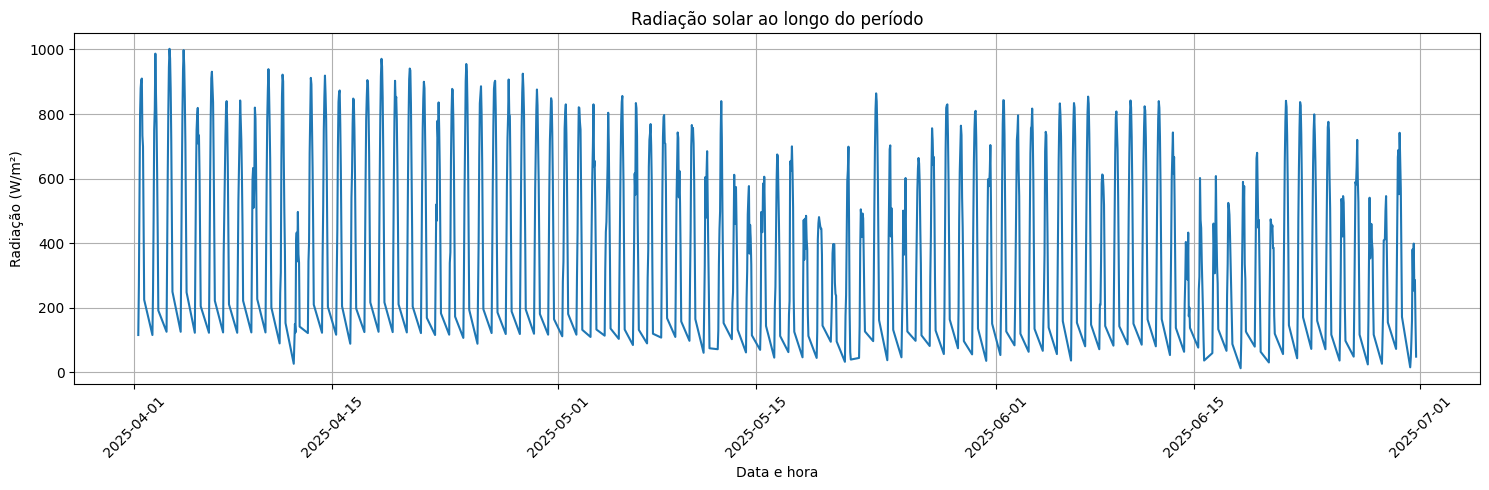

In [56]:
plt.figure(figsize=(15, 5))
plt.plot(df["data_hora"], df["radiacao_w_m2"])
plt.title("Radiação solar ao longo do período")
plt.xlabel("Data e hora")
plt.ylabel("Radiação (W/m²)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
X = df[
    [
        "temperatura_c",
        "umidade_pct",
        "nuvens_pct",
        "vento_kmh",
        "hora"
    ]
]

y = df["radiacao_w_m2"]

print("Variáveis de entrada (X):")
print(X.columns.tolist())

print("\nVariável alvo (y):")
print("radiacao_w_m2")

Variáveis de entrada (X):
['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']

Variável alvo (y):
radiacao_w_m2


In [31]:
indice = int(len(df) * 0.8)

X_train = X.iloc[:indice]
X_test = X.iloc[indice:]

y_train = y.iloc[:indice]
y_test = y.iloc[indice:]

print("Dados de treino:", len(X_train))
print("Dados de teste:", len(X_test))

print("\nÚltimo registro do treino:")
print(df.iloc[indice - 1]["data_hora"])

print("\nPrimeiro registro do teste:")
print(df.iloc[indice]["data_hora"])

Dados de treino: 800
Dados de teste: 201

Último registro do treino:
2025-06-12 14:00:00

Primeiro registro do teste:
2025-06-12 15:00:00


In [41]:
modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)
previsoes_linear = modelo_linear.predict(X_test)

In [46]:
modelo_floresta = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
modelo_floresta.fit(X_train, y_train)
previsoes_floresta = modelo_floresta.predict(X_test)

In [45]:
modelo_boosting = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
modelo_boosting.fit(X_train, y_train)
previsoes_boosting = modelo_boosting.predict(X_test)

In [47]:
def avaliar_modelo(nome, y_real, y_previsto):
    mae = mean_absolute_error(y_real, y_previsto)
    mse = mean_squared_error(y_real, y_previsto)
    r2 = r2_score(y_real, y_previsto)

    return {
        "Modelo": nome,
        "MAE (W/m²)": mae,
        "MSE ((W/m²)²)": mse,
        "R²": r2
    }

In [48]:
resultados = []

resultados.append(
    avaliar_modelo(
        "Regressão Linear",
        y_test,
        previsoes_linear
    )
)
resultados.append(
    avaliar_modelo(
        "Random Forest",
        y_test,
        previsoes_floresta
    )
)
resultados.append(
    avaliar_modelo(
        "Gradient Boosting",
        y_test,
        previsoes_boosting
    )
)
tabela_resultados = pd.DataFrame(resultados)
tabela_resultados

,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.204885,30034.201092,0.359845
1,Random Forest,66.804179,7307.417901,0.844248
2,Gradient Boosting,69.976194,7756.304776,0.834681


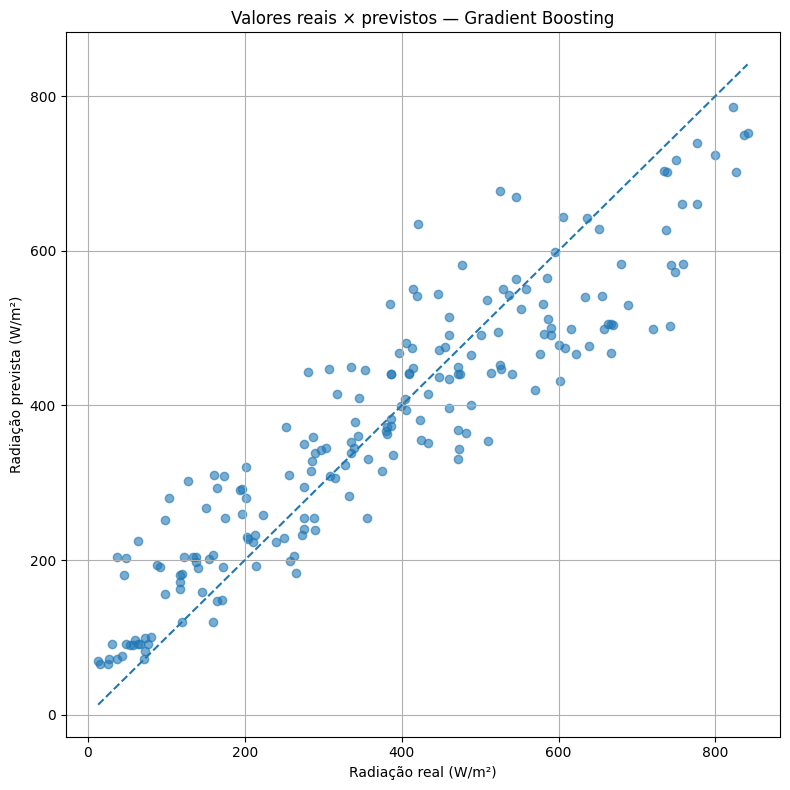

In [40]:
plt.figure(figsize=(8, 8))
plt.scatter(
    y_test,
    previsoes_boosting,
    alpha=0.6
)
limite_min = min(y_test.min(), previsoes_boosting.min())
limite_max = max(y_test.max(), previsoes_boosting.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)
plt.xlabel("Radiação real (W/m²)")
plt.ylabel("Radiação prevista (W/m²)")
plt.title("Valores reais × previstos — Gradient Boosting")

plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
importancias = pd.DataFrame({
    "Variável": X.columns,
    "Importância": modelo_floresta.feature_importances_
})
importancias = importancias.sort_values(
    "Importância",
    ascending=False
)
importancias

,Variável,Importância
4,hora,0.488455
0,temperatura_c,0.301028
1,umidade_pct,0.173311
2,nuvens_pct,0.021748
3,vento_kmh,0.015458


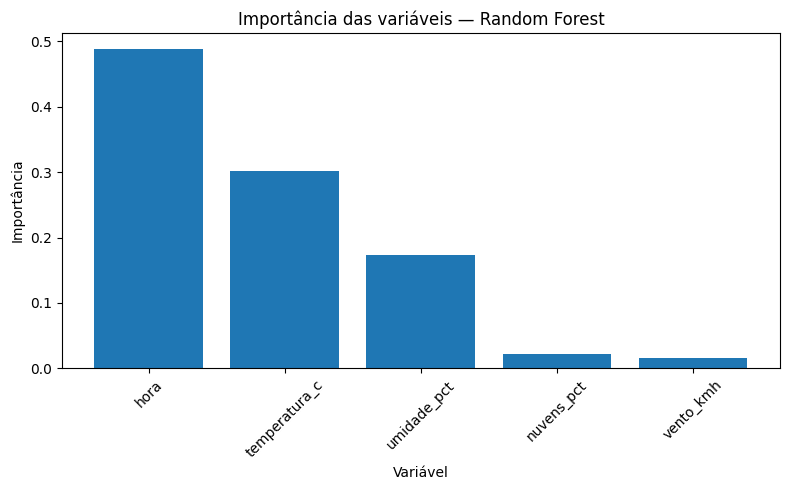

In [50]:
plt.figure(figsize=(8, 5))
plt.bar(
    importancias["Variável"],
    importancias["Importância"]
)
plt.title("Importância das variáveis — Random Forest")
plt.xlabel("Variável")
plt.ylabel("Importância")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
# 1. Preparação dos Dados
# O scikit-learn exige variáveis ​​numéricas. O dataframe já possui uma coluna 'hora' extraída,
# então podemos descartar o objeto datetime 'data_hora'.
X = df[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']]
y = df['radiacao_w_m2']

# Divisão em dados de treino e teste (80% para treino, 20% para teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Treinamento dos Modelos
# Instanciando e treinando a Regressão Linear
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Instanciando e treinando o Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Instanciando e treinando o Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# 3. Avaliação das Métricas
def avaliar_modelo(nome, y_true, y_pred):
    print(f"--- {nome} ---")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.2f}")
    print(f"R²: {r2_score(y_true, y_pred):.2f}\n")

avaliar_modelo("Regressão Linear", y_test, lr_pred)
avaliar_modelo("Random Forest", y_test, rf_pred)
avaliar_modelo("Gradient Boosting", y_test, gb_pred)

--- Regressão Linear ---
MAE: 121.59
MSE: 24816.37
R²: 0.62

--- Random Forest ---
MAE: 48.33
MSE: 4816.96
R²: 0.93

--- Gradient Boosting ---
MAE: 51.25
MSE: 4776.16
R²: 0.93



In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Tratamento de Dados e Limpeza
# Removemos qualquer linha que contenha valores nulos para evitar falhas no treinamento
df_clean = df.dropna().copy()

# Definimos as características (X) e o alvo (y)
X = df_clean[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']]
y = df_clean['radiacao_w_m2']

# Divisão em dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Escalonamento (Padronização)
# Extremamente importante para o desempenho da Regressão Linear
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Treinamento dos Modelos
# Regressão Linear
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# Random Forest (Modelos baseados em árvore não exigem escalonamento, mas não são prejudicados por ele)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)

# 4. Avaliação de Performance
def avaliar_modelo(nome, y_true, y_pred):
    print(f"--- {nome} ---")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.2f}")
    print(f"R²: {r2_score(y_true, y_pred):.2f}\n")

avaliar_modelo("Regressão Linear", y_test, lr_pred)
avaliar_modelo("Random Forest", y_test, rf_pred)
avaliar_modelo("Gradient Boosting", y_test, gb_pred)

--- Regressão Linear ---
MAE: 121.59
MSE: 24816.37
R²: 0.62

--- Random Forest ---
MAE: 48.31
MSE: 4813.74
R²: 0.93

--- Gradient Boosting ---
MAE: 51.26
MSE: 4767.42
R²: 0.93



### Conclusão

Foram utilizados três algoritmos de regressão diferentes: Regressão Linear, Random Forest Regressor e Gradient Boosting Regressor. Todos os modelos utilizaram a mesma divisão dos dados, mantendo a ordem temporal, com aproximadamente 80% das primeiras horas para treinamento e 20% das horas finais para teste.

As métricas utilizadas foram MAE, MSE e R². O MAE representa o erro médio absoluto da previsão em W/m². O MSE penaliza erros maiores de forma mais intensa, pois os erros são elevados ao quadrado. Já o R² indica o quanto da variação da variável alvo é explicada pelo modelo, sendo que valores mais próximos de 1 indicam maior capacidade de explicação dos dados.

A variável `hora` possui importância relevante porque a radiação solar apresenta um comportamento diretamente relacionado ao ciclo diário. Durante as horas próximas ao meio do dia, normalmente existe maior disponibilidade de radiação solar, enquanto no início e no final do período analisado os valores tendem a ser menores. Dessa forma, informar a hora do registro fornece ao modelo uma informação importante sobre o padrão esperado da radiação.

As variáveis meteorológicas também contribuem para a estimativa. A cobertura de nuvens, por exemplo, pode afetar diretamente a quantidade de radiação que chega à superfície. Temperatura, umidade e vento também podem apresentar relações com as condições atmosféricas observadas.

É importante destacar que a estimativa de `radiacao_w_m2` não representa automaticamente a energia elétrica produzida por um sistema fotovoltaico. A radiação é uma condição disponível para os módulos, enquanto a geração elétrica depende também de fatores como potência instalada, eficiência dos painéis, área dos módulos, orientação e inclinação, temperatura dos módulos, sombreamento, perdas elétricas e eficiência do inversor.

Portanto, um modelo de regressão para estimar a radiação solar pode ser utilizado como uma etapa de previsão das condições solares, mas não deve ser interpretado diretamente como uma previsão da quantidade de energia elétrica gerada pelo sistema fotovoltaico.
